/var/folders/s2/nry612l527j2xxdsq0_70h6m0000gn/T/ipykernel_56376/3473190419.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [S]


/Users/elizabethmurphy/miniconda3/envs/SRTI/lib/python3.13/site-packages/rich/live.py:231: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 10 seconds.
There were 23 divergences after tuning. Increase `target_accept` or reparameterize.


Text(0.5, 0, 'Days before detection')

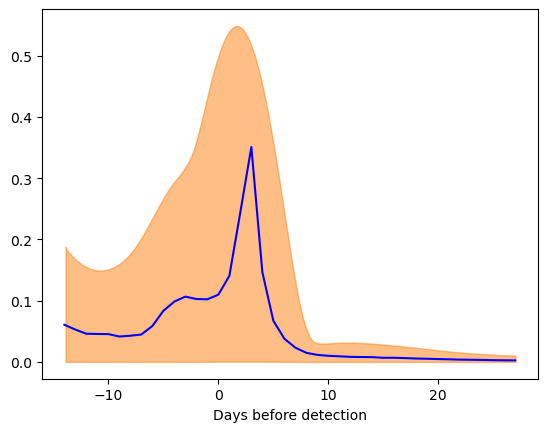

In [224]:
import numpy as np
import pymc as pm
import arviz as az
import pandas as pd 
import pickle
import json
# import requests
from scipy import signal
from datetime import date,timedelta
# import yaml
import copy

import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

start = pd.to_datetime('2023-01-01')
eval_dates = [start + datetime.timedelta(days=7*j) for j in range(0,52)]


# option 2: use SD county data, resolved by catchment. 
cases = pd.read_csv('/Users/elizabethmurphy/Downloads/cases.csv',index_col=0)
cases = cases[cases['catchment'] =='PointLoma']
cases = cases[(cases.index>='2021-04-01') & (cases.index<='2022-07-01')]
cases.index = pd.to_datetime(cases.index)
cases = cases.groupby(pd.Grouper(freq='D'))[['new_cases']].sum()
cases['cases'] = cases['new_cases'].rolling(window=7, center=True, min_periods=0).mean()
ww_dict = {'Point Loma':['/Users/elizabethmurphy/Downloads/PointLoma_sewage_seqs.csv','/Users/elizabethmurphy/Downloads/PointLoma_sewage_qPCR.csv']}
for site, files in zip(ww_dict.keys(),ww_dict.values()):
    df = pd.read_csv(f'{files[0]}')

    df['Date'] = pd.to_datetime(df['Date'])
    df.columns = [dfc.split(' (')[0] for dfc in df.columns]
    df =df.set_index('Date')
    df = df[df.index>='2021-04-01']
    df = df[df.index<='2022-07-01']
    df = df.dropna(axis = 0, how = 'all')
    df = df.fillna(0)
    df = df/100.

    df = df.drop(columns=['Other'])
    df = df[df.columns[df.sum(axis=0) > 0.01]]

    cdf = pd.read_csv(f'{files[1]}')
    cdf['Sample_Date'] = pd.to_datetime(cdf['Sample_Date'])
    cdf =cdf.set_index('Sample_Date')

    cdf = cdf.resample('D').asfreq()
    cdf = cdf.rolling(window=7, center=True, min_periods=0).mean()
    sharedInds = np.sort(list(set(cdf.index) & set(cases.index)))
    cdf = cdf.loc[sharedInds]



minInd = np.max([cdf.index.min(),cases.index.min()])
maxInd = np.min([cdf.index.max(),cases.index.max()])

cdf = cdf[cdf.index>=minInd]
cdf = cdf[cdf.index<=maxInd]

cases = cases[cases.index>=minInd]
cases = cases[cases.index<=maxInd]

cdf = pd.concat([cdf,cases],axis=1)
cdf = cdf.dropna(how='any')

N = 42
F = 14
X = np.array([cdf['cases'].values[(j-F):(j+N-F)] for j in range(F,(cdf.shape[0]-N+F))])#/cdf['cases'].mean()
Y = np.array(cdf['Mean viral gene copies/L'].values[F:(len(cdf['Mean viral gene copies/L'])-N+F)])/cdf['Mean viral gene copies/L'].mean()


with pm.Model() as shedding_model:
    S = pm.HalfFlat("S",shape=N)
    mu = pm.math.dot(X, S)
    Y_obs = pm.Gamma("Y_obs", alpha = mu/50, beta=50, observed=Y)
    trace = pm.sample(1000, return_inferencedata=True)


lags = np.arange(N) - F
fig,ax = plt.subplots()
az.plot_hdi(lags, trace.posterior["S"].values, hdi_prob=0.95,ax=ax)
ax.plot(lags, np.median(trace.posterior["S"].values,axis=(0,1)), color="blue")
ax.set_xlabel("Days before detection")

Text(0, 0.5, 'Cases')

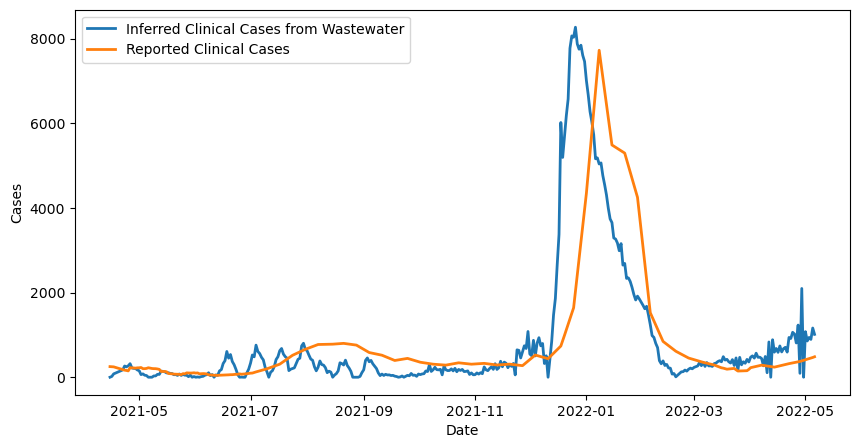

In [225]:
from numpy.fft import fft, ifft

S = np.median(trace.posterior["S"].values, axis=(0, 1))
S = S / S.sum()

VL = cdf['Mean viral gene copies/L'].rolling(window=7, center=True, min_periods=0).mean()
VL = VL[F:(len(VL)-N+F)]
VL = VL / np.mean(VL) * np.mean(Y)

def inverse(VL, S):
    length = len(VL) - len(S)
    S_pad = np.pad(S, (0, length), mode='constant')
    VL_fft = fft(VL)
    S_fft = fft(S_pad)
    H = S_fft
    H_T = np.conj(H)
    y = VL_fft
    C = (H_T * y) / (H_T * H)

    C = np.real(ifft(C))
    C[C < 0] = 0
    return C

C = inverse(VL, S)

reported = cdf['cases'].values[F:(len(cdf['cases'])-N+F)]
C_rescaled = C * (np.mean(reported) / np.mean(C))
C_rescaled = C_rescaled[:-28]

C_dates = cdf.index[F:(len(cdf.index)-N+F)]
C_dates_inv = C_dates[:len(C_rescaled)]

plt.figure(figsize=(10, 5))
plt.plot(C_dates_inv, C_rescaled, label='Inferred Clinical Cases from Wastewater', linewidth=2)
plt.plot(C_dates_inv, reported[:len(C_rescaled)], label='Reported Clinical Cases', linewidth=2)
plt.legend()
plt.xlabel('Date')
plt.ylabel('Cases')

In [226]:
import pandas as pd
import numpy as np
from scipy.stats import gamma, poisson

import epyestim
import epyestim.covid19 as covid19

ch_cases = pd.Series(C[:-28], index=C_dates_inv).round().astype(int)

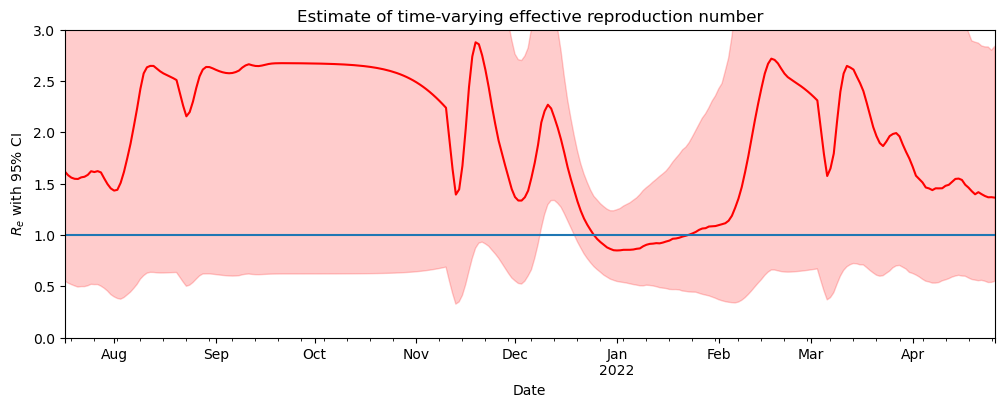

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-04-22,1.0,1.473038,0.347398,0.556895,1.396004,2.840438
2022-04-23,1.0,1.452537,0.345176,0.548515,1.378327,2.830868
2022-04-24,1.0,1.448925,0.341234,0.535969,1.365953,2.829923
2022-04-25,1.0,1.440791,0.345426,0.536929,1.366948,2.797521
2022-04-26,1.0,1.444982,0.346931,0.546887,1.362606,2.836559


In [227]:
ch_time_varying_r = covid19.r_covid(ch_cases)

ch_time_varying_r.tail()

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r.loc[:,'Q0.5'].plot(ax=ax, color='red')
ax.fill_between(ch_time_varying_r.index, 
                    ch_time_varying_r['Q0.025'], 
                    ch_time_varying_r['Q0.975'], 
                    color='red', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

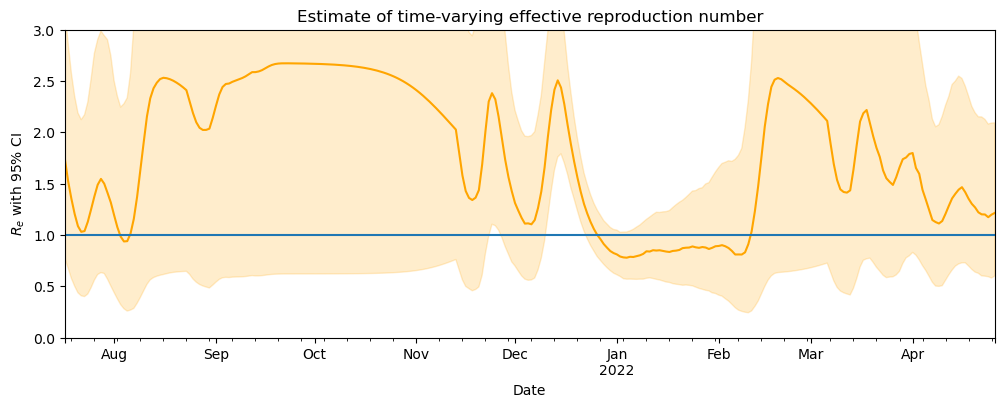

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-04-22,1.0,1.473038,0.347398,0.556895,1.396004,2.840438
2022-04-23,1.0,1.452537,0.345176,0.548515,1.378327,2.830868
2022-04-24,1.0,1.448925,0.341234,0.535969,1.365953,2.829923
2022-04-25,1.0,1.440791,0.345426,0.536929,1.366948,2.797521
2022-04-26,1.0,1.444982,0.346931,0.546887,1.362606,2.836559


In [228]:
ch_time_varying_r_ = covid19.r_covid(ch_cases, smoothing_window=14, r_window_size=7)

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r_.loc[:,'Q0.5'].plot(ax=ax, color='orange')
ax.fill_between(ch_time_varying_r_.index, 
                    ch_time_varying_r_['Q0.025'], 
                    ch_time_varying_r_['Q0.975'], 
                    color='orange', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

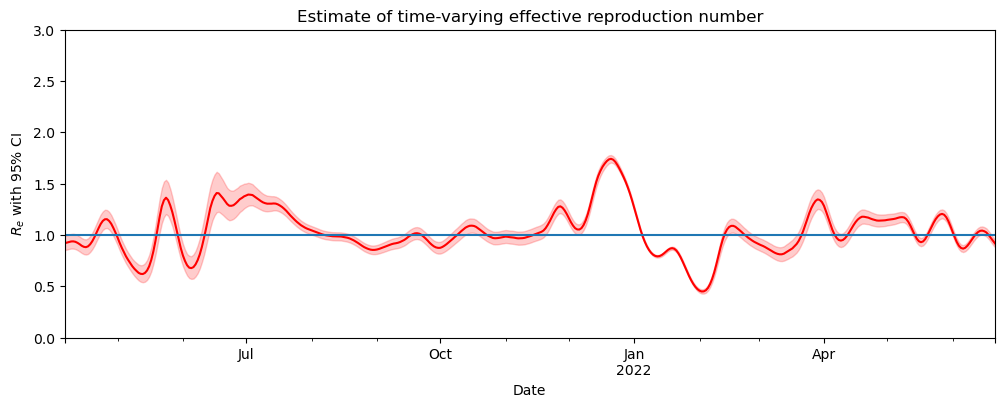

,cases,R_mean,R_var,Q0.025,Q0.5,Q0.975
2022-06-17,892.0,1.023793,0.000404,0.984855,1.023662,1.063475
2022-06-18,1024.0,1.000612,0.000391,0.962383,1.000483,1.039765
2022-06-19,1007.0,0.972863,0.000378,0.935152,0.972733,1.011433
2022-06-20,990.0,0.943706,0.000365,0.906675,0.943577,0.981468
2022-06-21,973.0,0.918760,0.000358,0.882043,0.918630,0.956107


In [229]:
# TEST ON CLINICAL DATA
reported_cases = pd.Series(cases['cases'].values, index=cases.index).round().astype(int)

ch_time_varying_r = covid19.r_covid(reported_cases)

fig, ax = plt.subplots(1,1, figsize=(12, 4))

ch_time_varying_r.loc[:,'Q0.5'].plot(ax=ax, color='red')
ax.fill_between(ch_time_varying_r.index, 
                    ch_time_varying_r['Q0.025'], 
                    ch_time_varying_r['Q0.975'], 
                    color='red', alpha=0.2)
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$ with 95% CI')
ax.set_ylim([0,3])
ax.axhline(y=1)
ax.set_title('Estimate of time-varying effective reproduction number')
plt.show()

ch_time_varying_r.tail()

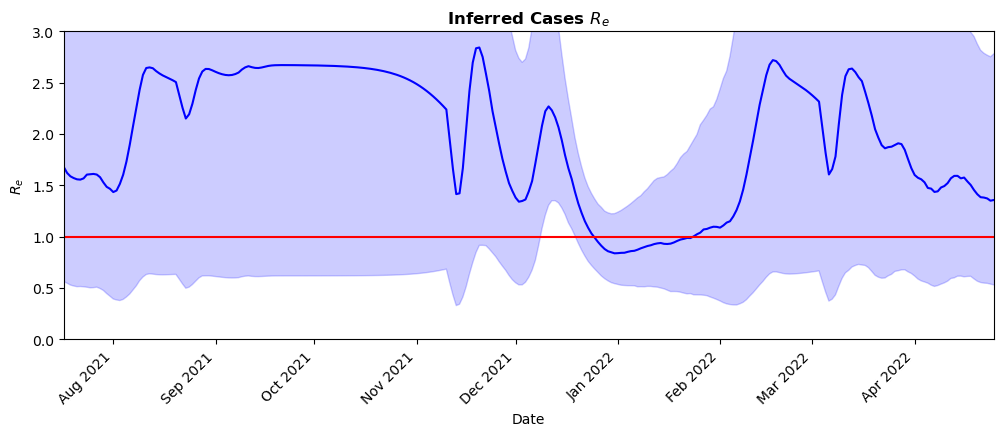

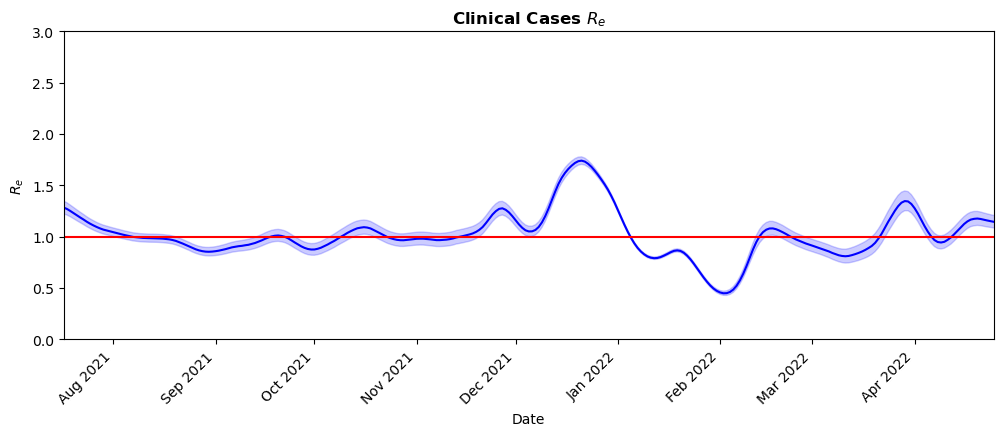

In [ ]:
# PLOTS FOR POSTER
min_len = min(len(C), len(C_dates_inv))

ch_cases = pd.Series(C[:min_len], index=C_dates_inv[:min_len]).round().astype(int)
reported_cases = pd.Series(cases['cases'].values, index=cases.index).round().astype(int)

inferred = covid19.r_covid(ch_cases)
reported = covid19.r_covid(reported_cases)

import matplotlib.ticker as mticker
import matplotlib.dates as mdates


xmin = pd.to_datetime("2021-07-17")
xmax = pd.to_datetime("2022-04-25")

fig, ax = plt.subplots(1,1, figsize=(12, 4))
inferred.loc[:,'Q0.5'].plot(ax=ax, color='blue')
ax.fill_between(inferred.index, 
                    inferred['Q0.025'], 
                    inferred['Q0.975'], 
                    color='blue', alpha=0.2)
ax.set_ylim([0, 3])
ax.axhline(y=1, color='red')
ax.set_xlim(xmin, xmax)
ax.set_title('Inferred Cases $R_e$', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()


fig, ax = plt.subplots(1,1, figsize=(12, 4))
reported.loc[:,'Q0.5'].plot(ax=ax, color='blue')
ax.fill_between(reported.index, 
                    reported['Q0.025'], 
                    reported['Q0.975'], 
                    color='blue', alpha=0.2)
ax.set_ylim([0, 3])
ax.axhline(y=1, color='red')
ax.set_xlim(xmin, xmax)
ax.set_title('Clinical Cases $R_e$', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('$R_e$')
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()

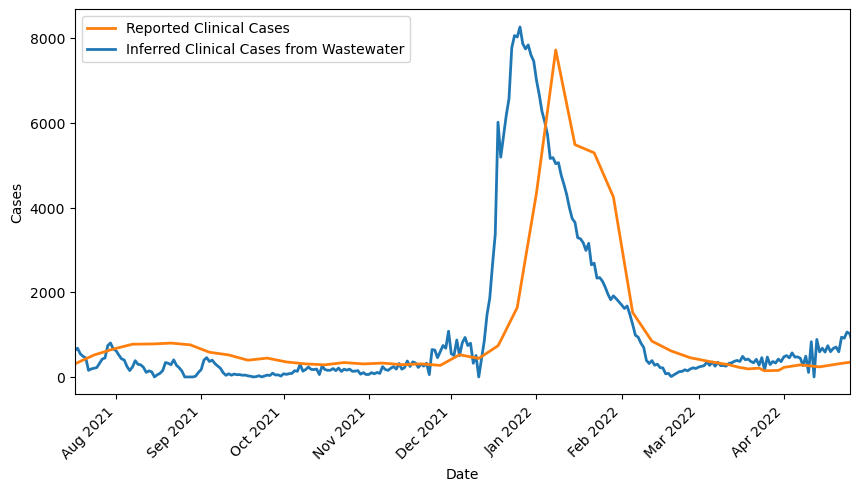

In [ ]:
# PLOTS FOR POSTER

C = inverse(VL, S)

reported = cdf['cases'].values[F:(len(cdf['cases'])-N+F)]
C_rescaled = C * (np.mean(reported) / np.mean(C))
C_rescaled = C_rescaled[:-28]

C_dates = cdf.index[F:(len(cdf.index)-N+F)]
C_dates_inv = C_dates[:len(C_rescaled)]

plt.figure(figsize=(10, 5))
line1, = plt.plot(C_dates_inv, C_rescaled, label='Inferred Clinical Cases from Wastewater', linewidth=2)
line2, = plt.plot(C_dates_inv, reported[:len(C_rescaled)], label='Reported Clinical Cases', linewidth=2)
plt.legend([line2, line1], ['Reported Clinical Cases', 'Inferred Clinical Cases from Wastewater'])
plt.xlabel('Date')
plt.ylabel('Cases')
ax = plt.gca()
ax.set_xlim(xmin, xmax)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonthday=1))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.show()